# 03b_RNN_HPTuning

RNN 단독 실험. **3-Fold Stratified CV**로 하이퍼파라미터 탐색 후 최적 파라미터로 최종 학습.

- 입력: 윈도우(30×2) 원본 시계열, V·I만 사용
- 탐색 대상: hidden1, hidden2, dropout, lr, batch_size
- 평가: 윈도우 단위 Precision / Recall / F1 / ROC-AUC / PR-AUC

In [42]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current device index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("Using CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
Current device index: 0
GPU name: NVIDIA GeForce RTX 5060 Ti


In [43]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])

0

In [44]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'comparison_raw_model'
MODEL_DIR.mkdir(exist_ok=True)

SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

RNN_HIDDEN_1        = 64
RNN_HIDDEN_2        = 32
DROPOUT_RATE        = 0.3
EPOCHS              = 200
BATCH_SIZE          = 32
LEARNING_RATE       = 1e-3
EARLY_STOP_PATIENCE = 20
RANDOM_SEED         = 42

print(f'WINDOW_SIZE: {WINDOW_SIZE}, STEP_SIZE: {STEP_SIZE}')

WINDOW_SIZE: 30, STEP_SIZE: 10


In [45]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report,
                              roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score)
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| Device:', DEVICE)

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
print('3-Fold StratifiedKFold 준비 완료')

PyTorch: 2.11.0+cu128 | Device: cuda
3-Fold StratifiedKFold 준비 완료


In [46]:
# =========================
# 데이터 로드 (V, I만 / Trial z-score)
# =========================

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue
    data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mean, std = data.mean(0), data.std(0)
    std[std < 1e-8] = 1e-8
    records.append({'folder': d.name, 'label': label, 'split': split,
                    'data': (data - mean) / std})

def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1])               for s in buckets}

n_feat = X['train'].shape[2]   # 2
scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):4d}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

train  total= 364  normal= 183  abnormal= 181
val    total=  58  normal=  29  abnormal=  29
test   total= 150  normal=  95  abnormal=  55


In [47]:
# =========================
# 공통 평가 함수 (윈도우 단위, threshold=0.5)
# =========================

roc_data = {}
results  = {}

def evaluate(model_name, y_true, y_prob):
    y_pred  = (y_prob >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    prec    = precision_score(y_true, y_pred, zero_division=0)
    rec     = recall_score(y_true, y_pred, zero_division=0)
    f1      = f1_score(y_true, y_pred, zero_division=0)

    print(f'\n===== {model_name} (threshold=0.5) =====')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')

    roc_data[model_name] = (y_true, y_prob)
    results[model_name]  = {'precision': prec, 'recall': rec, 'f1': f1,
                             'roc_auc': roc_auc, 'pr_auc': pr_auc}

print('평가 함수 준비 완료')

평가 함수 준비 완료


In [48]:
# =========================
# RNN — 3-Fold Stratified CV 하이퍼파라미터 탐색
# fold별 best_epoch 기록 → 최종 학습 epoch 수로 사용
# =========================

import random

class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.rnn1  = nn.RNN(n_features, hidden1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2  = nn.RNN(hidden1, hidden2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.rnn1(x);  out = self.drop1(out)
        out, _ = self.rnn2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


Xs_tv = np.vstack([Xs['train'], Xs['val']])
ys_tv = np.concatenate([y['train'], y['val']]).astype(np.float32)

rnn_param_dist = {
    'hidden1':    [32, 64, 128],
    'hidden2':    [16, 32, 64],
    'dropout':    [0.2, 0.3, 0.5],
    'lr':         [1e-3, 5e-4],
    'batch_size': [16, 32],
}

N_ITER      = 20
CV_EPOCHS   = 100
CV_PATIENCE = 10

random.seed(RANDOM_SEED)
sampled_params = [
    {k: random.choice(v) for k, v in rnn_param_dist.items()}
    for _ in range(N_ITER)
]

crit           = nn.BCELoss()
cv_results     = []
best_cv_auc    = -1
best_rnn_params = None

for i, params in enumerate(sampled_params):
    fold_aucs, fold_epochs = [], []

    for fold, (tr_idx, vl_idx) in enumerate(cv3.split(Xs_tv, ys_tv.astype(int))):
        X_tr, X_vl = Xs_tv[tr_idx], Xs_tv[vl_idx]
        y_tr, y_vl = ys_tv[tr_idx], ys_tv[vl_idx]

        mdl = RNNAnomalyDetector(n_feat, params['hidden1'],
                                  params['hidden2'], params['dropout']).to(DEVICE)
        opt = torch.optim.Adam(mdl.parameters(), lr=params['lr'])
        tr_dl = DataLoader(WindowDataset(X_tr, y_tr), params['batch_size'], shuffle=True)
        vl_dl = DataLoader(WindowDataset(X_vl, y_vl), params['batch_size'])

        best_loss = float('inf'); pc = 0; best_ep = 1
        for ep in range(1, CV_EPOCHS + 1):
            mdl.train()
            for Xb, yb in tr_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); crit(mdl(Xb), yb).backward(); opt.step()
            mdl.eval()
            with torch.no_grad():
                vl_loss = (sum(crit(mdl(Xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                               for Xb, yb in vl_dl) / len(vl_dl.dataset))
            if vl_loss < best_loss:
                best_loss = vl_loss; pc = 0; best_ep = ep
            else:
                pc += 1
                if pc >= CV_PATIENCE: break

        fold_epochs.append(best_ep)

        mdl.eval()
        probs, trues = [], []
        with torch.no_grad():
            for Xb, yb in vl_dl:
                probs.append(mdl(Xb.to(DEVICE)).cpu().numpy())
                trues.append(yb.numpy())
        try:
            auc = roc_auc_score(np.concatenate(trues).astype(int), np.concatenate(probs))
        except Exception:
            auc = 0.5
        fold_aucs.append(auc)

    mean_auc = float(np.mean(fold_aucs))
    avg_ep   = int(round(np.mean(fold_epochs)))
    cv_results.append({'params': params, 'cv_auc': mean_auc,
                       'fold_aucs': fold_aucs, 'fold_epochs': fold_epochs,
                       'avg_epoch': avg_ep})
    print(f'[{i+1:2d}/{N_ITER}] h1={params["hidden1"]:3d} h2={params["hidden2"]:2d} '
          f'drop={params["dropout"]} lr={params["lr"]} bs={params["batch_size"]:2d} '
          f'| CV AUC={mean_auc:.4f}  epochs={fold_epochs}→avg={avg_ep}')

    if mean_auc > best_cv_auc:
        best_cv_auc     = mean_auc
        best_rnn_params = params

best_result    = next(r for r in cv_results if r['params'] == best_rnn_params)
avg_best_epoch = best_result['avg_epoch']

print(f'\n최적 파라미터  : {best_rnn_params}')
print(f'CV best ROC-AUC: {best_cv_auc:.4f}')
print(f'최종 학습 epoch: {avg_best_epoch}  (CV fold 평균)')

[ 1/20] h1=128 h2=16 drop=0.2 lr=0.0005 bs=16 | CV AUC=0.8521  epochs=[32, 53, 49]→avg=45
[ 2/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | CV AUC=0.6518  epochs=[3, 70, 38]→avg=37
[ 3/20] h1=128 h2=32 drop=0.2 lr=0.001 bs=16 | CV AUC=0.5096  epochs=[10, 1, 12]→avg=8
[ 4/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | CV AUC=0.6171  epochs=[2, 1, 97]→avg=33
[ 5/20] h1=128 h2=64 drop=0.5 lr=0.0005 bs=16 | CV AUC=0.5726  epochs=[1, 1, 70]→avg=24
[ 6/20] h1= 64 h2=64 drop=0.3 lr=0.001 bs=16 | CV AUC=0.4720  epochs=[1, 1, 24]→avg=9
[ 7/20] h1=128 h2=32 drop=0.3 lr=0.0005 bs=16 | CV AUC=0.6115  epochs=[1, 1, 33]→avg=12
[ 8/20] h1= 32 h2=32 drop=0.2 lr=0.001 bs=32 | CV AUC=0.5925  epochs=[1, 1, 63]→avg=22
[ 9/20] h1= 32 h2=32 drop=0.3 lr=0.0005 bs=16 | CV AUC=0.5921  epochs=[1, 7, 84]→avg=31
[10/20] h1=128 h2=32 drop=0.5 lr=0.001 bs=32 | CV AUC=0.5323  epochs=[1, 1, 51]→avg=18
[11/20] h1= 32 h2=64 drop=0.3 lr=0.0005 bs=16 | CV AUC=0.5774  epochs=[2, 1, 57]→avg=20
[12/20] h1=128 h2=16 drop=0.2 lr=0.0

학습 epoch: 45  (CV fold 평균)
Epoch   1/45  train_loss=0.7025
Epoch  20/45  train_loss=0.6116
Epoch  40/45  train_loss=0.4465

최종 학습 완료  파라미터: {'hidden1': 128, 'hidden2': 16, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 16}


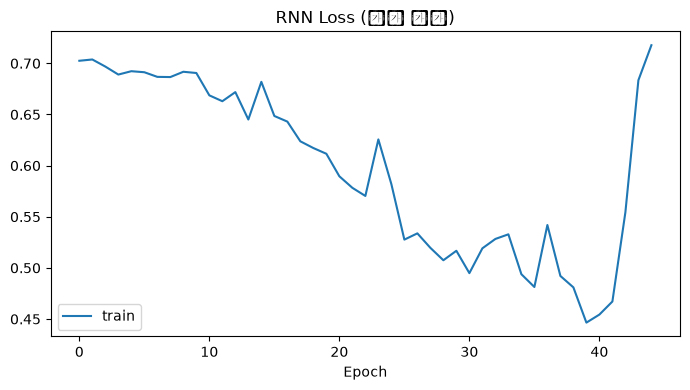

In [49]:
# =========================
# RNN — 최적 파라미터로 최종 학습
# epoch 수 = CV fold 평균 best_epoch → early stop 없음
# =========================

rnn_model = RNNAnomalyDetector(n_feat,
                                best_rnn_params['hidden1'],
                                best_rnn_params['hidden2'],
                                best_rnn_params['dropout']).to(DEVICE)
rnn_optim = torch.optim.Adam(rnn_model.parameters(), lr=best_rnn_params['lr'])

final_dl = DataLoader(WindowDataset(Xs_tv, ys_tv),
                       best_rnn_params['batch_size'], shuffle=True)

rnn_path = str(MODEL_DIR / 'best_rnn.pt')
history  = {'train_loss': []}

print(f'학습 epoch: {avg_best_epoch}  (CV fold 평균)')
for epoch in range(1, avg_best_epoch + 1):
    rnn_model.train()
    tr_loss = 0
    for Xb, yb in final_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        rnn_optim.zero_grad()
        loss = crit(rnn_model(Xb), yb)
        loss.backward(); rnn_optim.step()
        tr_loss += loss.item() * len(yb)
    tr_loss /= len(final_dl.dataset)
    history['train_loss'].append(tr_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{avg_best_epoch}  train_loss={tr_loss:.4f}')

torch.save(rnn_model.state_dict(), rnn_path)
print(f'\n최종 학습 완료  파라미터: {best_rnn_params}')

plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train')
plt.title('RNN Loss (최종 학습)'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'rnn_loss.png'), dpi=150)
plt.show()

In [50]:
# =========================
# RNN 평가 (윈도우 단위, threshold=0.5)
# =========================

rnn_model.eval()
all_prob, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        all_prob.append(rnn_model(Xb.to(DEVICE)).cpu().numpy())
        all_true.append(yb.numpy())

rnn_prob = np.concatenate(all_prob)
rnn_true = np.concatenate(all_true).astype(int)
evaluate('RNN', rnn_true, rnn_prob)


===== RNN (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.66      0.80      0.72        95
 Abnormal(1)       0.44      0.27      0.34        55

    accuracy                           0.61       150
   macro avg       0.55      0.54      0.53       150
weighted avg       0.58      0.61      0.58       150

ROC-AUC : 0.5449  |  PR-AUC : 0.4466


=== Window-level 비교 (threshold=0.5, Raw Window Input) ===
Model  Precision  Recall    F1  ROC-AUC  PR-AUC
  RNN      0.441   0.273 0.337    0.545   0.447


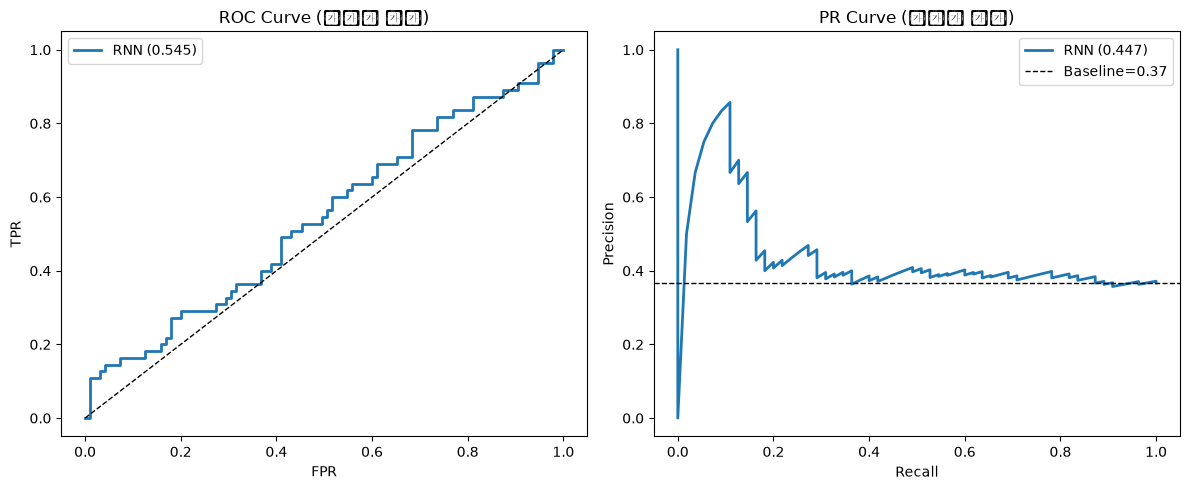

In [52]:
 # =========================
# 비교 요약 + ROC/PR 곡선
# =========================

df = pd.DataFrame([
    {
        'Model':     name,
        'Precision': round(v['precision'], 3),
        'Recall':    round(v['recall'],    3),
        'F1':        round(v['f1'],        3),
        'ROC-AUC':   round(v['roc_auc'],   3),
        'PR-AUC':    round(v['pr_auc'],    3),
    }
    for name, v in results.items()
])
print('=== Window-level 비교 (threshold=0.5, Raw Window Input) ===')
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))

for (name, (yt, yp)), c in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, lw=2, color=c,
                 label=f'{name} ({roc_auc_score(yt, yp):.3f})')
    pre, rec, _ = precision_recall_curve(yt, yp)
    axes[1].plot(rec, pre, lw=2, color=c,
                 label=f'{name} ({average_precision_score(yt, yp):.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (윈도우 단위)'); axes[0].legend()

baseline = list(roc_data.values())[0][0].mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve (윈도우 단위)'); axes[1].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'roc_pr_comparison.png'), dpi=150)
plt.show()